# Confusion Matrix and Classification Metrics

This notebook loads a trained PyTorch `.pt` model, runs it on a dataset, and computes a confusion matrix plus common classification metrics (accuracy, precision, recall, F1, and a per-class report).

In [33]:
import json
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import datasets, transforms, models
from PIL import Image

import numpy as np
import pandas as pd

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Basic configuration – wired to your MobileNetV2 training setup

BASE = Path(".").resolve()
DATA_DIR = BASE / "combined_dataset"
INDEX_CSV = DATA_DIR / "combined_index.csv"
LABELS_JSON = DATA_DIR / "labels.json"
LABEL2ID_JSON = DATA_DIR / "label2id.json"

# Use the best MobileNetV2 checkpoint produced by MobileNetV2_Training.ipynb
MODEL_PATH = BASE / "checkpoints" / "mobilenetv2_best.pt"

# Which split to evaluate: "val" or "test"
SPLIT_NAME = "test"

BATCH_SIZE = 32
IMAGE_SIZE = 224
NUM_WORKERS = 0  # safer default on Windows

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Using split: {SPLIT_NAME}")

Device: cpu
Using split: test


In [35]:
# Create dataset and dataloader compatible with your training notebook

assert INDEX_CSV.exists(), f"Missing CSV index: {INDEX_CSV}"
assert LABEL2ID_JSON.exists(), f"Missing label2id mapping: {LABEL2ID_JSON}"
assert LABELS_JSON.exists(), f"Missing labels.json: {LABELS_JSON}"

with open(LABEL2ID_JSON, "r", encoding="utf-8") as f:
    label2id = json.load(f)
with open(LABELS_JSON, "r", encoding="utf-8") as f:
    id2label = json.load(f)

num_classes = len(label2id)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class IndexDataset(torch.utils.data.Dataset):
    def __init__(self, index_csv, split_name, base_path, transform=None):
        self.base = Path(base_path)
        self.df = pd.read_csv(index_csv)
        self.df = self.df[self.df["split"] == split_name].reset_index(drop=True)
        self.transform = transform

    def _resolve_path(self, raw_path: str) -> Path:
        path = Path(raw_path)
        if not path.is_absolute():
            path = self.base / path
        else:
            parts = list(path.parts)
            if "DatasetRasaRight" in parts:
                idx = parts.index("DatasetRasaRight")
                relative_inside = Path(*parts[idx + 1 :])
                path = self.base / relative_inside
        return path

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        # Keep moving forward until we find an existing image
        start_i = i
        while True:
            row = self.df.iloc[i]
            path = self._resolve_path(row["path"])

            if path.exists():
                img = Image.open(path).convert("RGB")
                label_id = int(row["label_id"])
                if self.transform:
                    img = self.transform(img)
                return img, label_id

            i = (i + 1) % len(self.df)
            if i == start_i:
                raise FileNotFoundError("No valid image files found in dataset")


dataset = IndexDataset(INDEX_CSV, SPLIT_NAME, BASE, transform=eval_transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

class_names = [id2label[str(i)] for i in range(num_classes)]

print(f"Split '{SPLIT_NAME}' samples:", len(dataset))
print("Number of classes:", num_classes)

Split 'test' samples: 5418
Number of classes: 65


In [36]:
# Load the model from the .pt file (MobileNetV2 checkpoint)

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model file not found at: {MODEL_PATH}")

try:
    base_model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
except Exception:
    base_model = models.mobilenet_v2(pretrained=True)

in_features = base_model.classifier[1].in_features
base_model.classifier[1] = nn.Linear(in_features, num_classes)

ckpt = torch.load(MODEL_PATH, map_location=device)
if "model_state_dict" in ckpt:
    base_model.load_state_dict(ckpt["model_state_dict"])
else:
    base_model.load_state_dict(ckpt)

model = base_model.to(device)
model.eval()

print("Loaded model type:", model.__class__.__name__)

Loaded model type: MobileNetV2


In [37]:
# Run inference and collect predictions

all_y_true = []
all_y_pred = []

with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)  # shape: [batch_size, num_classes]
        _, preds = torch.max(outputs, dim=1)

        all_y_true.extend(labels.cpu().numpy())
        all_y_pred.extend(preds.cpu().numpy())

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

print("Total samples:", len(all_y_true))

Total samples: 5418


In [39]:
# Compute overall metrics and per-class report

accuracy = accuracy_score(all_y_true, all_y_pred)
precision_macro = precision_score(all_y_true, all_y_pred, average="macro", zero_division=0)
recall_macro = recall_score(all_y_true, all_y_pred, average="macro", zero_division=0)
f1_macro = f1_score(all_y_true, all_y_pred, average="macro", zero_division=0)

precision_weighted = precision_score(all_y_true, all_y_pred, average="weighted", zero_division=0)
recall_weighted = recall_score(all_y_true, all_y_pred, average="weighted", zero_division=0)
f1_weighted = f1_score(all_y_true, all_y_pred, average="weighted", zero_division=0)

print("=== Global Metrics ===")
print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision (macro)   : {precision_macro:.4f}")
print(f"Recall (macro)      : {recall_macro:.4f}")
print(f"F1-score (macro)    : {f1_macro:.4f}")
print()
print(f"Precision (weighted): {precision_weighted:.4f}")
print(f"Recall (weighted)   : {recall_weighted:.4f}")
print(f"F1-score (weighted) : {f1_weighted:.4f}")

print("\n=== Detailed Classification Report ===")

# Only include classes that actually appear in this split
used_labels = sorted(np.unique(np.concatenate([all_y_true, all_y_pred])))
used_class_names = [class_names[i] for i in used_labels]

print(
    classification_report(
        all_y_true,
        all_y_pred,
        labels=used_labels,
        target_names=used_class_names,
        digits=4,
        zero_division=0,
    )
)

=== Global Metrics ===
Accuracy            : 0.5816
Precision (macro)   : 0.3881
Recall (macro)      : 0.3081
F1-score (macro)    : 0.3310

Precision (weighted): 0.9831
Recall (weighted)   : 0.5816
F1-score (weighted) : 0.6370

=== Detailed Classification Report ===
                     precision    recall  f1-score   support

         Apam Balik     0.9962    0.1179    0.2109      2239
        Bak Kut Teh     1.0000    0.7727    0.8718        22
       Beef Rendang     0.8182    0.6000    0.6923        15
           Bibimbap     0.9853    0.8375    0.9054        80
            Biryani     0.9091    0.8621    0.8850        58
        Boiled Eggs     1.0000    0.4000    0.5714        15
             Burger     0.9962    0.9351    0.9647      1124
             Cendol     1.0000    0.8947    0.9444        19
     Char Kuey Teow     0.9524    0.9091    0.9302       110
          Char Siew     1.0000    0.9600    0.9796        25
         Cheesecake     0.8889    0.8000    0.8421       100


Confusion Matrix (counts):
                     Apam Balik  Bak Kut Teh  Beef Rendang  Bibimbap  Biryani  \
Apam Balik                  264            0             0         0        0   
Bak Kut Teh                   0           17             0         1        0   
Beef Rendang                  0            0             9         0        1   
Bibimbap                      0            0             0        67        0   
Biryani                       0            0             0         0       50   
Boiled Eggs                   0            0             0         0        0   
Burger                        0            0             0         0        0   
Cendol                        0            0             0         0        0   
Char Kuey Teow                0            0             0         0        1   
Char Siew                     0            0             0         0        0   
Cheesecake                    0            0             0         0        0   
C

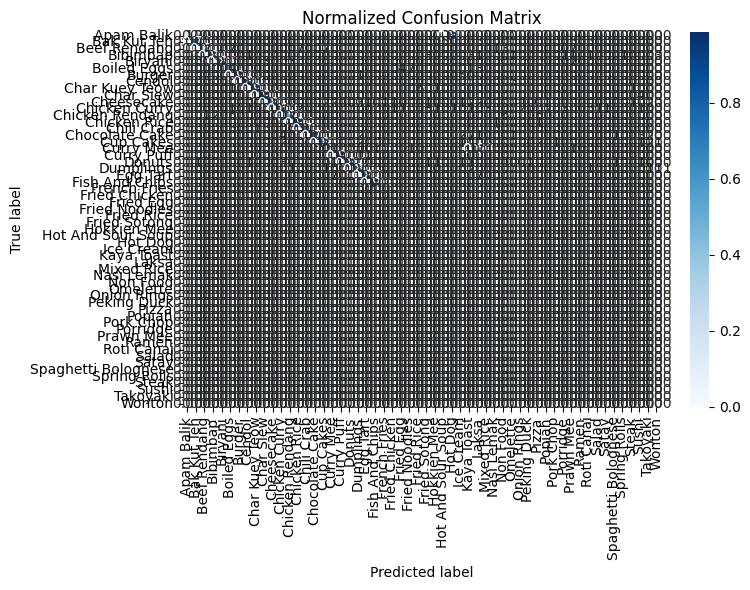

In [41]:
# Confusion matrix (counts and normalized heatmap)

# Use only the labels that actually appear in this split
used_labels = sorted(np.unique(np.concatenate([all_y_true, all_y_pred])))
used_class_names = [class_names[i] for i in used_labels]

cm = confusion_matrix(all_y_true, all_y_pred, labels=used_labels)
cm_norm = confusion_matrix(all_y_true, all_y_pred, labels=used_labels, normalize="true")

print("Confusion Matrix (counts):")
print(pd.DataFrame(cm, index=used_class_names, columns=used_class_names))

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=used_class_names,
    yticklabels=used_class_names,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In [42]:
# Optional: save a summary of the main metrics to a JSON file

metrics = {
    "accuracy": float(accuracy),
    "precision_macro": float(precision_macro),
    "recall_macro": float(recall_macro),
    "f1_macro": float(f1_macro),
    "precision_weighted": float(precision_weighted),
    "recall_weighted": float(recall_weighted),
    "f1_weighted": float(f1_weighted),
    "classes": class_names,
}

out_file = Path("metrics_summary.json")
out_file.write_text(json.dumps(metrics, indent=2))
print(f"Saved metrics to: {out_file.resolve()}")

Saved metrics to: C:\Users\Asus\OneDrive\Desktop\DatasetRasaRight\metrics_summary.json
